#3. Polynomial Regression

### 공부 시간에 따른 시험 점수 (우등생)

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
dataset = pd.read_csv('/content/drive/MyDrive/PythonMLWorkspace/SciKitLearn/PolynomialRegressionData.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# **3-1 단순 선형 회귀 (Simple Linear Regression)**

In [71]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X, y) # 전체 데이터로 학습

LinearRegression()

### 데이터 시각화 (전체)

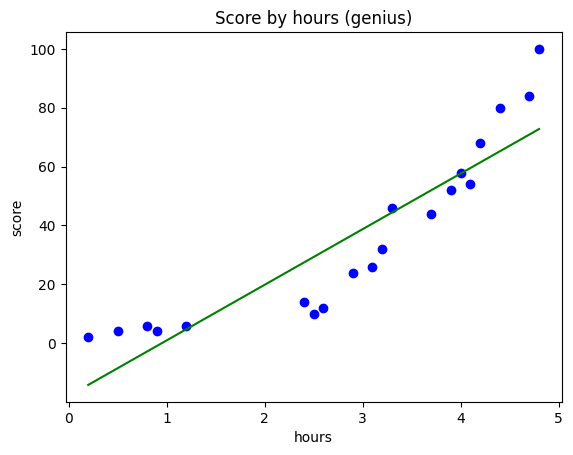

In [72]:
plt.scatter(X, y, color='blue') # 산점도
plt.plot(X, reg.predict(X), color='green') # 선 그래프
plt.title('Score by hours (genius)') # 제목
plt.xlabel('hours') # x 축 이름
plt.ylabel('score') # y 축 이름
plt.show()

In [73]:
reg.score(X, y) # 전체 데이터를 통한 점수

0.8169296513411765

## 3-2 다항 회귀 (Polynomial Regression)
따로 클래스를 제공하지는 않음 >> 매번 x에 대한 fit_transform 을 해줘야 함!!

In [74]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
X_poly[:5] # 피처가 확장되었음 >> x의 n승까지 확장된 것.
# [x] -> [x^0, x^1, x^2]로 확장

array([[1.0000e+00, 2.0000e-01, 4.0000e-02, 8.0000e-03, 1.6000e-03],
       [1.0000e+00, 5.0000e-01, 2.5000e-01, 1.2500e-01, 6.2500e-02],
       [1.0000e+00, 8.0000e-01, 6.4000e-01, 5.1200e-01, 4.0960e-01],
       [1.0000e+00, 9.0000e-01, 8.1000e-01, 7.2900e-01, 6.5610e-01],
       [1.0000e+00, 1.2000e+00, 1.4400e+00, 1.7280e+00, 2.0736e+00]])

In [75]:
X[:5]

array([[0.2],
       [0.5],
       [0.8],
       [0.9],
       [1.2]])

In [76]:
poly_reg.get_feature_names_out()

array(['1', 'x0', 'x0^2', 'x0^3', 'x0^4'], dtype=object)

In [77]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y) # 변환된 X와 y를 가지고 모델 생성 [학습]

LinearRegression()

### 데이터 시각화 (변환된 X와 y)

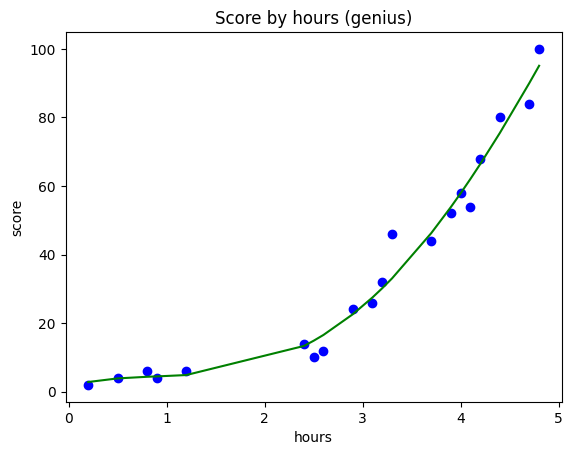

In [78]:
plt.scatter(X, y, color='blue');
plt.plot(X, lin_reg.predict(poly_reg.fit_transform(X)), color='green')
plt.title('Score by hours (genius)') # 제목
plt.xlabel('hours') # x 축 이름
plt.ylabel('score') # y 축 이름
plt.show()

In [79]:
X_range = np.arange(min(X), max(X), 0.1) # X의 최솟값과 최댓값 사이를 0.1 단위로 잘라서 생성
X_range # 하지만 이거를 그대로 사용할 수는 없다. X_range는 46개를 가지는 일차원 배열이고 X는 X[:5] 를 보면 2차원 배열이다.

/tmp/ipykernel_21138/2214344504.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_range = np.arange(min(X), max(X), 0.1) # X의 최솟값과 최댓값 사이를 0.1 단위로 잘라서 생성


array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4,
       1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7,
       2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. ,
       4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7])

In [80]:
X_range = X_range.reshape(-1, 1) # row 를 자동계산해라 >> -1, col는 한 개 >> 1
X_range.shape


(46, 1)

In [81]:
X_range[:5]

array([[0.2],
       [0.3],
       [0.4],
       [0.5],
       [0.6]])

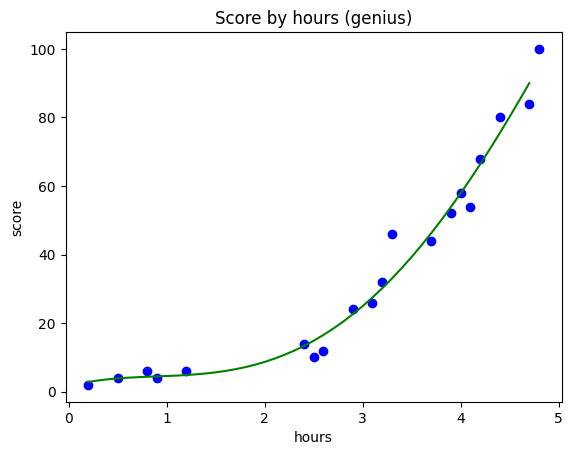

In [82]:
plt.scatter(X, y, color='blue');
plt.plot(X_range, lin_reg.predict(poly_reg.fit_transform(X_range)), color='green')
plt.title('Score by hours (genius)') # 제목
plt.xlabel('hours') # x 축 이름
plt.ylabel('score') # y 축 이름
plt.show()

### 공부 시간에 따른 시험 성적 예측

In [83]:
reg.predict([[2]]) # 2시간을 공부했을 때 선형회귀 모델의 예측

array([19.85348988])

In [84]:
lin_reg.predict(poly_reg.fit_transform([[2]])) # 2시간을 공부했을 때 다항 회귀 모델의 예측 >> 바로 [[2]] 를 넣을 수 없고,
                                               # 5개의 피처 (x^0 ~ x^4) 로 fit_transform 한 [[2]]를 넣어야 함

array([8.70559135])

In [85]:
lin_reg.score(X_poly, y)

0.9782775579000046